# Aprendizaxe automático - Práctica 3

## Redes convolucionais

**Luis Barba Cepedello, Rubén Pérez Sangiao, Daniel Piqueras Valle**

## Implementación dunha arquitectura MLP modular

In [1]:
import torch
from torch import nn

# Clase que define un MLP xenérico
class MLP(nn.Module):
    def __init__(self, input_neurons, output_neurons, hidden_layers):
        # Parámetros:
        # input_neurons: Número de neuronas da capa de entrada
        # output_neurons: Número de neuronas da capa de saída
        # hidden_layers: Lista onde cada elemento representa o número de neuronas dunha capa oculta

        # Chamamos ao constructor da clase nai
        super(MLP, self).__init__()

        # Lista onde iremos engadindo cada unha das capas
        layers = []

        # O número de entradas da primeira capa é 'input_neurons'
        current_input = input_neurons

        # Iteramos sobre a lista de capas ocultas para construír a rede paso a paso
        for hidden_neurons in hidden_layers:
            # Engadimos a capa lineal
            layers.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))

            # Engadimos a función de activación RELU (hai que ter en conta que non se aplica á última)
            layers.append(nn.ReLU())

            # A saída desta capa será a entrada da seguinte
            current_input = hidden_neurons

        # Unha vez engadidas todas as capas ocultas, engadimos a capa de saída
        layers.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        # nn.Sequential permítenos empaquetar a lista de capas nun único módulo que as executará en orde secuencial cando se faga o forward
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Definimos o método forward, que é chamado cando se pasa unha imaxe pola rede

        # Aplicamos o aplanamento
        x = torch.flatten(x, start_dim=1)

        # Pasamos os datos pola nosa secuencia de capas
        predicted_probs = self.network(x)
        return predicted_probs

## Implementación dunha arquitectura CNN modular

In [2]:
# Clase que define unha rede neuronal convolucional xenérica.
class CNN(nn.Module):
    def __init__(self,
                 input_channels,
                 conv_layers,
                 first_conv_filters,
                 conv_kernel_size,
                 batch_norm,
                 hidden_mlp_layers,
                 output_neurons,
                 image_size=160): # Engadimos image_size para poder facer logo o flatten

        # Chamamos ao constructor da clase pai
        super(CNN, self).__init__()

        ### CONSTRUCIÓN DA PARTE CONVOLUCIONAL ###
        conv_modules = []
        in_c = input_channels
        out_c = first_conv_filters

        # Iteramos para crear as capas convolucionais
        for i in range(conv_layers):
            # Añadimos a capa convolucional
            # Empregamos o seguinte padding: conv_kernel_size // 2 para mantener as proporcións antes do pooling
            conv_modules.append(nn.Conv2d(in_channels=in_c,
                                          out_channels=out_c,
                                          kernel_size=conv_kernel_size,
                                          padding=conv_kernel_size // 2))

            # Normalización por lotes
            # Normalizamos antes de aplicar a ReLU, pero perfectamente podería facerse ao revés
            # Escollemos facelo así porque era o que recomendaban Sergey Ioffe e Christian Szegedy, os creadores da técnica
            if batch_norm:
                conv_modules.append(nn.BatchNorm2d(out_c))

            # Función de activación ReLU
            conv_modules.append(nn.ReLU())

            # Capa de Pooling
            # Asumimos un MaxPooling estándar de 2x2
            conv_modules.append(nn.MaxPool2d(kernel_size=2, stride=2))

            # Para a proxima capa a entrada son os filtros de salida actuales
            in_c = out_c
            # Doble número de filtros para a siguiente capa convolucional
            out_c *= 2

        self.cnn = nn.Sequential(*conv_modules)

        ### CONSTRUCIÓN DA PARTE MLP ###
        # Creamos un tensor falso do tamaño das nosas imaxes para pasalo pola rede convolucional
        # e así descubrir automáticamente cantas características salen tras todos os MaxPoolings.
        dummy_tensor = torch.zeros(1, input_channels, image_size, image_size)
        dummy_output = self.cnn(dummy_tensor)
        flattened_size = dummy_output.view(-1).shape[0]

        mlp_modules = []
        current_input = flattened_size

        # Iteramos sobre as capas ocultas do MLP
        for hidden_neurons in hidden_mlp_layers:
            mlp_modules.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))
            mlp_modules.append(nn.ReLU())
            current_input = hidden_neurons

        # Capa final de salida (sin función de activación)
        mlp_modules.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        self.mlp = nn.Sequential(*mlp_modules)

    def forward(self, x):
        x = self.cnn(x)

        # Aplanado final unidimensional para pasarllo ao MLP
        x = torch.flatten(x, start_dim=1)
        x = self.mlp(x)

        return x

In [3]:
import copy

# Función xenérica para adestrar unha época
def train(dataloader, model, loss_fn, optimizer, device="cpu", log=False):
    # Obtemos o número total de lotes
    num_images = len(dataloader.dataset)
    # Poñemos o modelo en modo de adestramento
    model.train()

    loss = 0.0
    n_batch = 0

    # Iteramos sobre os lotes
    for batch_imgs, batch_labels in dataloader:
        batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

        # Obtemos as predicións para o lote actual
        pred = model(batch_imgs)
        # Calculamos a perda
        loss = loss_fn(pred, batch_labels)
        # Poñemos a cero os gradientes dos parámetros do modelo
        optimizer.zero_grad()
        # Realizamos a retropropagación para calcular os gradientes de cada parámetro
        loss.backward()
        # Actualizamos os parámetros do modelo utilizando os gradientes calculados
        optimizer.step()

        # Calculamos o loss acumulado
        loss += loss.item() * batch_imgs.size(0)

        # Cada 100 lotes, imprimimos a perda e o progreso
        if log and n_batch % 100 == 0:
            loss, imgs_processed = loss.item(), n_batch * len(batch_imgs)
            print(f"perda: {loss:>7f}  [{imgs_processed:>5d}/{num_images:>5d}]")

        n_batch += 1

    return loss / len(dataloader.dataset)

# Función xenérica para avaliar o modelo (tanto para validación como para test)
def evaluate(dataloader, model, loss_fn, device="cpu"):
    # Poñemos o modelo en modo de avaliación (sen calcular gradientes)
    model.eval()
    # Inicializamos as variables para gardar a perda e a precisión
    loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_imgs, batch_labels in dataloader:
            batch_imgs, batch_labels = batch_imgs.to(device), batch_labels.to(device)

            # Obtemos as predicións para o lote actual
            pred = model(batch_imgs)
            # Calculamos a perda e acumulamos o valor
            # Nota: no tutorial non multiplicaba por batch_imgs.size, pero pensamos que era un erro
            # loss_fn calcula o erro medio do batch, logo hai que multiplicalo polo tamaño do batch para
            # poder despois dividir entre o total de datos e ter o dato correcto de loss
            loss += loss_fn(pred, batch_labels).item() * batch_imgs.size(0)

            _, predicted = torch.max(pred, 1)
            correct += (predicted == batch_labels).sum().item()
            total += batch_labels.size(0)

    val_loss = loss / total
    val_acc = (correct / total) * 100
    return val_loss, val_acc

## Adestramento e optimización de MLPs e CNNs nun problema real

### Obtención dos conxuntos de datos

In [4]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# Mirando a documentacion vimos que as imaxes non son cadradas asi que as redimensionamos
transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

# Particion de train de Imaginette, que dividiremos en conxuntos de adestramento e validación
full_train_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='train',
    size='160px', # Pillamos a versión de baixa resolución
    download=True,
    transform=transform
)

train_proportion = 0.85
train_size = int(train_proportion * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Particion de validación de Imaginette, que empregaremos para test
test_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='val',
    size='160px',
    download=True,
    transform=transform
)

print(f"Tamaño adestramento: {len(train_dataset)} imaxes.")
print(f"Tamaño validación: {len(val_dataset)} imaxes.")
print(f"Tamaño test: {len(test_dataset)} imaxes.")

# Creamos os dataloaders
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

imaxes, etiquetas = next(iter(train_loader))
print(f"Forma do tensor de imaxes (batch_size, canles, alto, ancho): {imaxes.shape}")

100%|██████████| 99.0M/99.0M [00:07<00:00, 13.2MB/s]


Tamaño adestramento: 8048 imaxes.
Tamaño validación: 1421 imaxes.
Tamaño test: 3925 imaxes.
Forma do tensor de imaxes (batch_size, canles, alto, ancho): torch.Size([8, 3, 160, 160])


### Adestramento dun MLP de proba

In [5]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 76800 neuronas de entrada porque as imaxes teñen un tamaño de 160 * 160 píxeles e 3 valores de RGB en cada un
mlp_model = MLP(input_neurons=76800, output_neurons=10, hidden_layers=[128, 64]).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
mlp_val_losses = []
mlp_val_accs = []
max_epochs = 30
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_mlp_wts = copy.deepcopy(mlp_model.state_dict())

print("--- Adestramento do MLP ---")
for epoch in range(max_epochs):
    # Adestramos e avaliamos
    train_loss = train(train_loader, mlp_model, loss_fn, optimizer_mlp, device, log=True)
    val_loss, val_acc = evaluate(val_loader, mlp_model, loss_fn, device)

    mlp_val_losses.append(val_loss)
    mlp_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping
    # Se non houbo mellora de loss, a paciencia se reduce
    # Cando a paciencia chegue a cero, detense o adestramento por épocas
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp_wts = copy.deepcopy(mlp_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Produciuse early stopping na época {epoch+1}!")
            break

# Restauramos os mellores pesos obtidos
mlp_model.load_state_dict(best_mlp_wts)
print("MLP adestrado e mellor modelo cargado.")

--- Adestramento do MLP ---
perda: 21.244091  [    0/ 8048]
perda: 24.517004  [  800/ 8048]
perda: 21.502350  [ 1600/ 8048]
perda: 23.322975  [ 2400/ 8048]
perda: 18.452183  [ 3200/ 8048]
perda: 21.602764  [ 4000/ 8048]
perda: 21.861578  [ 4800/ 8048]
perda: 21.334167  [ 5600/ 8048]
perda: 18.954437  [ 6400/ 8048]
perda: 19.993097  [ 7200/ 8048]
perda: 18.195309  [ 8000/ 8048]
Época 01 | Train Loss: 0.0018 | Val Loss: 2.0739 | Val Acc: 25.97%
perda: 20.554567  [    0/ 8048]
perda: 24.068058  [  800/ 8048]
perda: 18.242252  [ 1600/ 8048]
perda: 16.918812  [ 2400/ 8048]
perda: 20.845737  [ 3200/ 8048]
perda: 17.501062  [ 4000/ 8048]
perda: 15.589108  [ 4800/ 8048]
perda: 21.842455  [ 5600/ 8048]
perda: 14.638201  [ 6400/ 8048]
perda: 16.954481  [ 7200/ 8048]
perda: 20.378208  [ 8000/ 8048]
Época 02 | Train Loss: 0.0025 | Val Loss: 2.1369 | Val Acc: 19.21%
perda: 19.735548  [    0/ 8048]
perda: 14.075515  [  800/ 8048]
perda: 17.863474  [ 1600/ 8048]
perda: 20.111217  [ 2400/ 8048]
perda:

### Adestramento dunha CNN de proba

In [6]:
# Instanciamos a CNN
cnn_model = CNN(input_channels=3,
                conv_layers=3,
                first_conv_filters=16,
                conv_kernel_size=3,
                batch_norm=True,
                hidden_mlp_layers=[128],
                output_neurons=10,
                image_size=160).to(device)

optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
cnn_val_losses = []
cnn_val_accs = []
best_val_loss = float('inf')
patience_counter = 0
best_cnn_wts = copy.deepcopy(cnn_model.state_dict())

# Bucle análogo ao do MLP
print("--- Iniciando adestramento da CNN ---")
for epoch in range(max_epochs):
    train_loss = train(train_loader, cnn_model, loss_fn, optimizer_cnn, device, log=True)
    val_loss, val_acc = evaluate(val_loader, cnn_model, loss_fn, device)

    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_cnn_wts = copy.deepcopy(cnn_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Early Stopping na época {epoch+1}!")
            break

cnn_model.load_state_dict(best_cnn_wts)
print("CNN adestrada e mellor modelo cargado.")

--- Iniciando adestramento da CNN ---
perda: 22.174261  [    0/ 8048]
perda: 20.654398  [  800/ 8048]
perda: 17.681021  [ 1600/ 8048]
perda: 17.918331  [ 2400/ 8048]
perda: 18.749762  [ 3200/ 8048]
perda: 17.945192  [ 4000/ 8048]
perda: 14.663389  [ 4800/ 8048]
perda: 18.112473  [ 5600/ 8048]
perda: 8.275673  [ 6400/ 8048]
perda: 12.166949  [ 7200/ 8048]
perda: 8.352715  [ 8000/ 8048]
Época 01 | Train Loss: 0.0017 | Val Loss: 1.5685 | Val Acc: 47.50%
perda: 17.049862  [    0/ 8048]
perda: 13.014643  [  800/ 8048]
perda: 13.789778  [ 1600/ 8048]
perda: 7.540226  [ 2400/ 8048]
perda: 9.844172  [ 3200/ 8048]
perda: 11.865297  [ 4000/ 8048]
perda: 8.490635  [ 4800/ 8048]
perda: 19.890385  [ 5600/ 8048]
perda: 18.582207  [ 6400/ 8048]
perda: 7.425111  [ 7200/ 8048]
perda: 21.290983  [ 8000/ 8048]
Época 02 | Train Loss: 0.0015 | Val Loss: 1.3530 | Val Acc: 55.52%
perda: 6.701016  [    0/ 8048]
perda: 10.840868  [  800/ 8048]
perda: 9.681236  [ 1600/ 8048]
perda: 4.333395  [ 2400/ 8048]
perda

### Comparación directa entre o MLP e a CNN

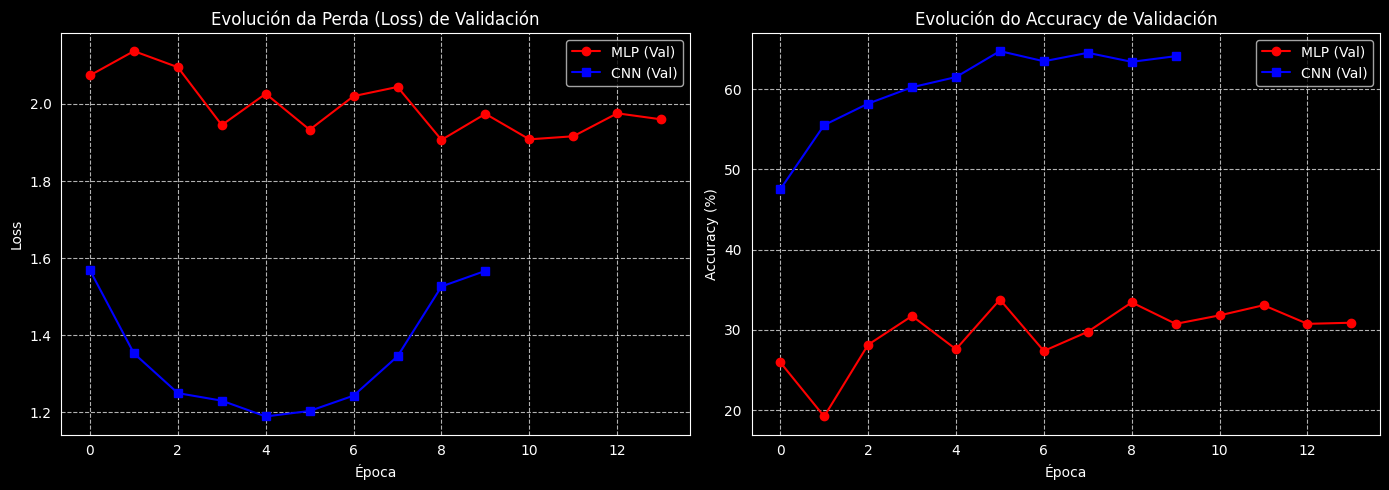

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(mlp_val_losses, label='MLP (Val)', color='red', marker='o')
ax1.plot(cnn_val_losses, label='CNN (Val)', color='blue', marker='s')
ax1.set_title('Evolución da Perda (Loss) de Validación')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Accuracy
ax2.plot(mlp_val_accs, label='MLP (Val)', color='red', marker='o')
ax2.plot(cnn_val_accs, label='CNN (Val)', color='blue', marker='s')
ax2.set_title('Evolución do Accuracy de Validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Adestramento de varios MLP e CNN

MLPs (5 arquitecturas): varían en profundidade (1–4 capas ocultas) e anchura, desde un MLP pequeno dun único nivel ata un máis fondo con catro capas.

CNNs (8 arquitecturas):
- As 6 primeiras varían a etapa convolucional (nº de capas, tamaño do kernel, nº de filtros iniciais, con/sen batch norm) mantendo o MLP fixo en [128].
- As 2 últimas usan a mesma etapa convolucional de referencia e varían o MLP ([256] e [256, 128]).

In [8]:
import copy
import torch.optim as optim

# --- ARQUITECTURAS DOS MLPs ---

# Cada entrada é un dicionario con nome e capas ocultas
mlp_configs = [
    {"name": "MLP_pequeno",   "hidden_layers": [256]},
    {"name": "MLP_medio",     "hidden_layers": [512, 256]},
    {"name": "MLP_fondo",     "hidden_layers": [512, 256, 128]},
    {"name": "MLP_ancho",     "hidden_layers": [1024, 512]},
    {"name": "MLP_moi_fondo", "hidden_layers": [512, 256, 128, 64]},
]

# --- ARQUITECTURAS DAS CNNs ---

# Cada entrada é un dicionario con:
# conv_layers: número de bloques conv+pool
# first_conv_filters: filtros no primeiro bloque (dóbranse en cada capa)
# conv_kernel_size: tamaño do kernel convolucional
# batch_norm: normalización por lotes
# hidden_mlp_layers: capas ocultas do MLP tras a parte convolucional
cnn_configs = [
    # Variedade na etapa convolucional (MLP fixo: [128])
    {"name": "CNN_conv2_k3_f16_bn",  "conv_layers": 2, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [128]},
    {"name": "CNN_conv3_k3_f16_bn",  "conv_layers": 3, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [128]},
    {"name": "CNN_conv3_k5_f16_bn",  "conv_layers": 3, "first_conv_filters": 16,  "conv_kernel_size": 5, "batch_norm": True,  "hidden_mlp_layers": [128]},
    {"name": "CNN_conv3_k3_f32_bn",  "conv_layers": 3, "first_conv_filters": 32,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [128]},
    {"name": "CNN_conv4_k3_f16_bn",  "conv_layers": 4, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [128]},
    {"name": "CNN_conv3_k3_f16_nobn","conv_layers": 3, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": False, "hidden_mlp_layers": [128]},
    # Variedade na etapa MLP (conv fixo: 3 capas, k=3, 16 filtros, batch_norm)
    {"name": "CNN_conv3_mlp_256",    "conv_layers": 3, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [256]},
    {"name": "CNN_conv3_mlp_256_128","conv_layers": 3, "first_conv_filters": 16,  "conv_kernel_size": 3, "batch_norm": True,  "hidden_mlp_layers": [256, 128]},
]

# --- FUNCIÓN PARA ADESTRAR UN MODELO POR ÉPOCAS CON EARLY STOPPING ---

def train_model(name, model, train_loader, val_loader, loss_fn, device,
                max_epochs=30, patience=5, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Variables para gardar os resultados
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    print(f"--- Adestramento de: {name} ---")

    for epoch in range(max_epochs):
        # --- Adestramento dunha época ---
        train_loss = train(train_loader, model, loss_fn, optimizer, device)

        # --- Validación ---
        val_loss, val_acc = evaluate(val_loader, model, loss_fn, device)

        print(f"Época {epoch+1:02d}/{max_epochs} | "
              f"\tTrain Loss: {train_loss:.4f} | "
              f"\tVal Loss: {val_loss:.4f} | "
              f"\tVal Acc: {val_acc:.2f}%")

        # --- Early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  -> Early stopping na época {epoch+1}.")
                break

    model.load_state_dict(best_weights)
    print(f"  Mellor Val Loss: {best_val_loss:.4f}")
    return model, best_val_loss

In [ ]:
# --- ADESTRAMENTO DOS MODELOS ---

loss_fn = nn.CrossEntropyLoss()
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dicionarios onde gardamos os modelos e as súas perdas finais
trained_models = {}
final_losses = {}

# --- MLPs ---

for cfg in mlp_configs:
    model = MLP(
        input_neurons=76800,
        output_neurons=10,
        hidden_layers=cfg["hidden_layers"]
    ).to(device)

    trained_model, best_loss = train_model(
        name=cfg["name"],
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        device=device
    )
    trained_models[cfg["name"]] = trained_model
    final_losses[cfg["name"]] = best_loss

# --- CNNs ---

for cfg in cnn_configs:
    model = CNN(
        input_channels=3,
        conv_layers=cfg["conv_layers"],
        first_conv_filters=cfg["first_conv_filters"],
        conv_kernel_size=cfg["conv_kernel_size"],
        batch_norm=cfg["batch_norm"],
        hidden_mlp_layers=cfg["hidden_mlp_layers"],
        output_neurons=10,
        image_size=160
    ).to(device)

    trained_model, best_loss = train_model(
        name=cfg["name"],
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_fn=loss_fn,
        device=device
    )
    trained_models[cfg["name"]] = trained_model
    final_losses[cfg["name"]] = best_loss

print("--- Mellor val_loss por modelo ---")
for name, loss in sorted(final_losses.items(), key=lambda x: x[1]):
    print(f"  {name:<35} Val Loss: {loss:.4f}")

--- Adestramento de: MLP_pequeno ---
Época 01/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3018 | 	Val Acc: 11.26%
Época 02/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.2958 | 	Val Acc: 11.89%
Época 03/30 | 	Train Loss: 0.0027 | 	Val Loss: 2.2976 | 	Val Acc: 11.75%
Época 04/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.2936 | 	Val Acc: 8.80%
Época 05/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3025 | 	Val Acc: 8.23%
Época 06/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3025 | 	Val Acc: 8.23%
Época 07/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3021 | 	Val Acc: 11.33%
Época 08/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3024 | 	Val Acc: 8.23%
Época 09/30 | 	Train Loss: 0.0026 | 	Val Loss: 2.3007 | 	Val Acc: 8.30%
  -> Early stopping na época 9.
  Mellor Val Loss: 2.2936
--- Adestramento de: MLP_medio ---
Época 01/30 | 	Train Loss: 0.0024 | 	Val Loss: 2.1526 | 	Val Acc: 20.48%
Época 02/30 | 	Train Loss: 0.0021 | 	Val Loss: 2.0314 | 	Val Acc: 26.88%
Época 03/30 | 	Train Loss: 0.0017 | 	Val Loss: 1.9739 | 	Val Acc: 29.63%

### Test e comparación dos modelos

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- TEST DOS MODELOS ---

print("--- TEST DOS MODELOS ---")

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Dicionario ao que accederemos por nome
test_results = {}

for name, model in trained_models.items():
    t_loss, t_acc = evaluate(test_loader, model, loss_fn, device)
    n_params = count_parameters(model)
    test_results[name] = {"loss": t_loss, "acc": t_acc, "params": n_params}
    print(f"  {name:<35} Loss: {t_loss:.4f} | Acc: {t_acc:.2f}% | Params: {n_params:,}")

# Separamos resultados de MLP e CNN
mlp_results = {k: v for k, v in test_results.items() if k.startswith("MLP")}
cnn_results = {k: v for k, v in test_results.items() if k.startswith("CNN")}

# --- GRÁFICAS DE ACCURACY FRONTE A CONFIGURACIÓN ---

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Accuracy no conxunto de test por configuración", fontsize=14, fontweight="bold")

for ax, results, title, color in zip(
    axes,
    [mlp_results, cnn_results],
    ["MLPs", "CNNs"],
    ["steelblue", "darkorange"]
):
    names  = list(results.keys())
    accs   = [results[n]["acc"] for n in names]
    # Etiquetas máis curtas (eliminamos o prefixo MLP_/CNN_)
    labels = [n.replace("MLP_", "").replace("CNN_", "") for n in names]

    bars = ax.bar(labels, accs, color=color, edgecolor="white", linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Configuración", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.set_ylim(0, max(accs) * 1.18)
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Valor enriba de cada barra
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{acc:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

    # Marca a mellor barra
    best_idx = accs.index(max(accs))
    bars[best_idx].set_edgecolor("gold")
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.show()

# --- GRÁFICAS DE ACCURACY FRONTE A NÚMERO DE PARÁMETROS ---

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Accuracy vs Número de parámetros", fontsize=14, fontweight="bold")

for ax, results, title, color in zip(
    axes,
    [mlp_results, cnn_results],
    ["MLPs", "CNNs"],
    ["steelblue", "darkorange"]
):
    names  = list(results.keys())
    params = [results[n]["params"] for n in names]
    accs   = [results[n]["acc"]    for n in names]
    labels = [n.replace("MLP_", "").replace("CNN_", "") for n in names]

    ax.scatter(params, accs, color=color, s=100, zorder=3, edgecolors="white", linewidth=0.8)

    # Etiqueta a cada punto
    for x, y, lbl in zip(params, accs, labels):
        ax.annotate(lbl, (x, y), textcoords="offset points", xytext=(6, 4),
                    fontsize=7.5, color="dimgray")

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Número de parámetros", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{int(x/1e3)}K"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# --- SELECCIÓN DOS MELLORES MODELOS ---

best_mlp_name = max(mlp_results, key=lambda n: mlp_results[n]["acc"])
best_cnn_name = max(cnn_results, key=lambda n: cnn_results[n]["acc"])

best_mlp_model = trained_models[best_mlp_name]
best_cnn_model = trained_models[best_cnn_name]

print("\n--- MELLORES MODELOS ---")
print(f"  Mellor MLP: {best_mlp_name}")
print(f"    Accuracy : {mlp_results[best_mlp_name]['acc']:.2f}%")
print(f"    Test Loss: {mlp_results[best_mlp_name]['loss']:.4f}")
print(f"    Parámetros: {mlp_results[best_mlp_name]['params']:,}")
print()
print(f"  Mellor CNN: {best_cnn_name}")
print(f"    Accuracy : {cnn_results[best_cnn_name]['acc']:.2f}%")
print(f"    Test Loss: {cnn_results[best_cnn_name]['loss']:.4f}")
print(f"    Parámetros: {cnn_results[best_cnn_name]['params']:,}")

## Resultados e conclusións